In [ ]:
from google.colab import files
uploaded = files.upload()

Saving cleaned_stroke_dataset.csv to cleaned_stroke_dataset.csv


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import joblib

In [ ]:
df = pd.read_csv("cleaned_stroke_dataset.csv")

In [ ]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,67.0,0,1,1,2,1,228.69,36.6,1,1
1,0,61.0,0,0,1,3,0,202.21,28.1,2,1
2,1,80.0,0,1,1,2,0,105.92,32.5,2,1
3,0,49.0,0,0,1,2,1,171.23,34.4,3,1
4,0,79.0,1,0,1,3,0,174.12,24.0,2,1


For Encode categorical columns
- to convert text into numerial form

In [ ]:
le = LabelEncoder()

categorical_cols = [
    'gender',
    'ever_married',
    'work_type',
    'Residence_type',
    'smoking_status'
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [ ]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,67.0,0,1,1,2,1,228.69,36.6,1,1
1,0,61.0,0,0,1,3,0,202.21,28.1,2,1
2,1,80.0,0,1,1,2,0,105.92,32.5,2,1
3,0,49.0,0,0,1,2,1,171.23,34.4,3,1
4,0,79.0,1,0,1,3,0,174.12,24.0,2,1


To define features and target

features

In [ ]:
X = df.drop('stroke', axis=1)

Target

In [ ]:
y = df['stroke']

To split dataset

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

To train logistic regression model

In [ ]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

make prediction

In [ ]:
y_pred_lr = lr_model.predict(X_test)

To check accuracy

In [ ]:
accuracy_score(y_test, y_pred_lr)

0.9393346379647749

Classification report

In [ ]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97       960
           1       0.00      0.00      0.00        62

    accuracy                           0.94      1022
   macro avg       0.47      0.50      0.48      1022
weighted avg       0.88      0.94      0.91      1022



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Confusion matrix

In [ ]:
cm = confusion_matrix(y_test, y_pred_lr)
print(cm)

[[960   0]
 [ 62   0]]


To train random forest model

In [ ]:
rf_model = RandomForestClassifier()

rf_model.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
y_pred_rf = rf_model.predict(X_test)

In [ ]:
accuracy_score(y_test, y_pred_rf)

0.9383561643835616

Random forest report

In [ ]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97       960
           1       0.00      0.00      0.00        62

    accuracy                           0.94      1022
   macro avg       0.47      0.50      0.48      1022
weighted avg       0.88      0.94      0.91      1022



In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)

[[959   1]
 [ 62   0]]


Feature importance

In [ ]:
importance = rf_model.feature_importances_

features = X.columns

feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

             Feature  Importance
7  avg_glucose_level    0.281070
1                age    0.238336
8                bmi    0.235328
9     smoking_status    0.068287
5          work_type    0.046500
0             gender    0.032207
6     Residence_type    0.030852
3      heart_disease    0.024108
2       hypertension    0.023303
4       ever_married    0.020009


Plot feature importance

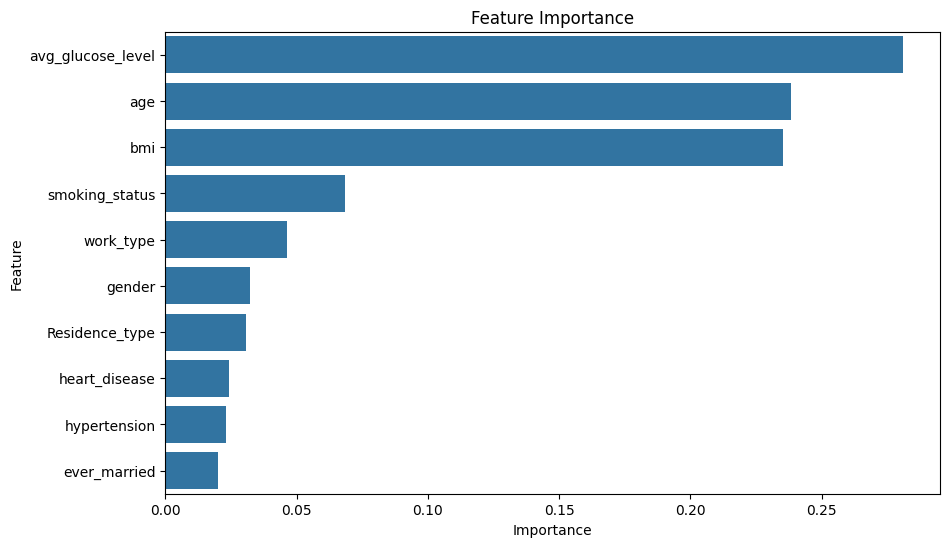

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Feature Importance")

plt.show()

In [ ]:
joblib.dump(rf_model, 'stroke_prediction_model.pkl')

['stroke_prediction_model.pkl']

In [ ]:
loaded_model = joblib.load('stroke_prediction_model.pkl')

Insights
- Age is a major factor affecting stroke prediction

- Glucose level strongly impacts stroke risk

- Random Forest performed better than Logistic Regression

- Dataset imbalance affected recall score

- Feature importance helped identify key biomarkers